# totalVI model training on longitudinal CITE-seq data

This notebook loads the preprocessed MuData object generated in the first notebook and trains a totalVI model to obtain an integrated RNA + ADT protein latent representation.

## 1. Import libraries

In [1]:
import os

import numpy as np
import pandas as pd
import scipy

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import muon
import scvi
import torch

/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## 2. Initial configuration

In [2]:
# Check modules
print("scanpy:", sc.__version__)
print("scvi-tools:", scvi.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Set seed for reproducibility
scvi.settings.seed = 0

# Figure configuration
sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

# PyTorch configuration
torch.set_float32_matmul_precision("high")


/tmp/ipykernel_39818/2844006475.py:2: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy:", sc.__version__)
Seed set to 0


scanpy: 1.11.5
scvi-tools: 1.3.3
torch: 2.12.0+cu130
CUDA available: True


## 3. Load preprocessed MuData object

In [3]:
mdata = muon.read_h5mu("../data/processed/citeseq_longitudinal_preprocessed.h5mu")

mdata

/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:565: UserWarning: Cannot join columns with the same name because var_names are intersecting.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the d

MuData object with n_obs × n_vars = 13112 × 37555
  3 modalities
    rna:	13112 × 33538
      obs:	'batch'
      var:	'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg', 'log1p'
      layers:	'counts'
    prot:	13112 × 17
    rna_subset:	13112 × 4000
      obs:	'batch'
      var:	'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg', 'log1p'
      layers:	'counts'

In [4]:
print("RNA:", mdata.mod["rna"].shape)
print("RNA subset:", mdata.mod["rna_subset"].shape)
print("Protein:", mdata.mod["prot"].shape)
print("RNA subset layers:", mdata.mod["rna_subset"].layers.keys())

RNA: (13112, 33538)
RNA subset: (13112, 4000)
Protein: (13112, 17)
RNA subset layers: KeysView(Layers with keys: counts)


## 4. Prepare MuData object for totalVI

In [5]:
# Convert sparse matrices to dense arrays
mdata.mod["prot"].X = mdata.mod["prot"].X.toarray()
mdata.mod["rna_subset"].X = mdata.mod["rna_subset"].X.toarray()
mdata.mod["rna_subset"].layers["counts"] = mdata.mod["rna_subset"].layers["counts"].toarray()


# Register the MuData object for totalVI
scvi.model.TOTALVI.setup_mudata(
    mdata,
    rna_layer="counts",
    protein_layer=None,
    batch_key="batch",
    modalities={
        "rna_layer": "rna_subset",
        "protein_layer": "prot",
        "batch_key": "rna_subset",
    },
)

mdata

MuData object with n_obs × n_vars = 13112 × 37555
  obs:	'_scvi_labels'
  uns:	'_scvi_uuid', '_scvi_manager_uuid'
  3 modalities
    rna:	13112 × 33538
      obs:	'batch'
      var:	'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg', 'log1p'
      layers:	'counts'
    prot:	13112 × 17
      obs:	'_scvi_batch'
    rna_subset:	13112 × 4000
      obs:	'batch', '_scvi_batch'
      var:	'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
      uns:	'hvg', 'log1p'
      layers:	'counts'

## 5. Train totalVI model

In [6]:
model = scvi.model.TOTALVI(mdata)

model.train(early_stopping=True)

INFO     Computing empirical prior initialization for protein background.                                          


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/lightning/pytorch/core/optimizer.py:317: The lr scheduler dict contains the key(s) ['monitor'], but the keys will be ignored. You need to call `lr_scheduler.step()` manually in manual optimization.
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' doe

Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


## 6. Check model training history

In [7]:
last_val_valid = np.array(model.history["elbo_validation"])[-1]
last_val_train = np.array(model.history["elbo_train"])[-1]

global_min_loss = min(
    np.min(model.history["elbo_train"]),
    np.min(model.history["elbo_validation"]),
)

last_max_loss = max(last_val_train, last_val_valid)[0]

global_max_loss = max(
    np.max(model.history["elbo_train"]),
    np.max(model.history["elbo_validation"]),
)

In [8]:
# Compute the min and max of both train and validation losses
min_loss = min(min(last_val_train, last_val_valid), global_min_loss)
max_loss = max(max(last_val_train, last_val_valid), global_max_loss)

ylim_min = 0.995 * min_loss  # 0.5% below the minimum
ylim_max = min(
    global_max_loss,
    ylim_min + (last_max_loss - ylim_min) * 4,
)  # keep it under the 25% part of figure

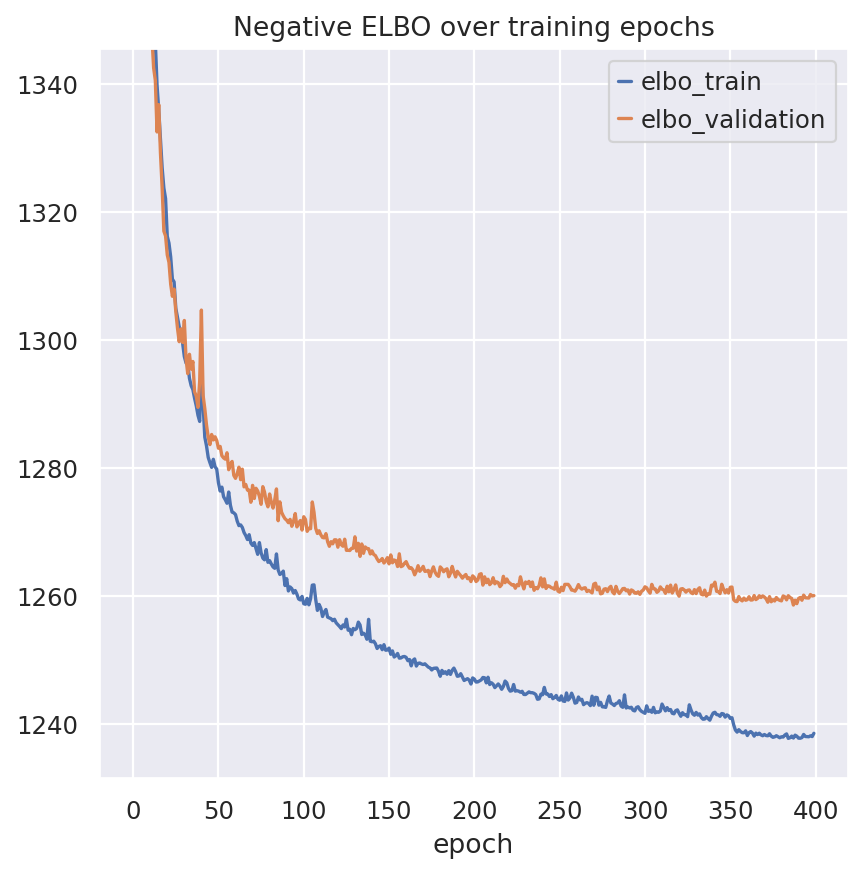

In [9]:
fig, ax = plt.subplots(1, 1)

model.history["elbo_train"].plot(ax=ax, label="train")
model.history["elbo_validation"].plot(ax=ax, label="validation")

if isinstance(ylim_min, (int, float)) and isinstance(ylim_max, (int, float)):
    ax.set(title="Negative ELBO over training epochs", ylim=(ylim_min, ylim_max))
else:
    ax.set(title="Negative ELBO over training epochs")

ax.legend()

In [10]:
os.makedirs("../results/figures", exist_ok=True)

fig.savefig(
    "../results/figures/totalvi_training_elbo.png",
    dpi=300,
    bbox_inches="tight"
)

## 7. Save trained model and latent representation

In [11]:
# Store totalVI latent representation in the MuData object
mdata.mod["rna_subset"].obsm["X_totalVI"] = model.get_latent_representation()

# Define output paths
trained_mdata_path = "../data/processed/citeseq_longitudinal_totalvi_trained.h5mu"
model_dir = "../results/models/totalvi_longitudinal_model"

# Create model directory if it does not exist
os.makedirs(model_dir, exist_ok=True)

# Save trained MuData object and totalVI model
mdata.write(trained_mdata_path)
model.save(model_dir, overwrite=True)

print(f"Trained MuData object saved to: {trained_mdata_path}")
print(f"totalVI model saved to: {model_dir}")

Trained MuData object saved to: ../data/processed/citeseq_longitudinal_totalvi_trained.h5mu
totalVI model saved to: ../results/models/totalvi_longitudinal_model


/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/dags/miniconda3/envs/totalvi_env/lib/python3.10/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [12]:
!ls -lh ../data/processed/
!ls -lh ../results/models/

total 1.2G
-rw-r--r-- 1 dags dags 425M May 27 12:37 citeseq_longitudinal_preprocessed.h5mu
-rw-r--r-- 1 dags dags 742M May 27 13:36 citeseq_longitudinal_totalvi_trained.h5mu
total 4.0K
drwxr-xr-x 2 dags dags 4.0K May 27 13:36 totalvi_longitudinal_model
